# Multi-Human Tracking System: Complete Production Pipeline

This notebook extends YOLOv8 human detection with:
- SORT/Deep SORT multi-object tracking
- Kalman filter motion prediction
- Trajectory registration and analysis
- MOT metrics evaluation
- Real-time video processing
- Export in multiple formats



## Cell 1: Installation & Dependencies



In [29]:
import subprocess
import sys

print("Installing dependencies...")
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scipy'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pandas'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'seaborn'], check=False)
print("Dependencies installed!")



Installing dependencies...
Dependencies installed!


## Cell 2: Import Libraries



In [30]:
import numpy as np
import cv2
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import torch
from ultralytics import YOLO
import json
import csv
import logging
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("All imports successful!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



All imports successful!
PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


## Cell 3: Define Detection Class



In [31]:
@dataclass
class Detection:
    """Single frame detection result"""
    x1: float
    y1: float
    x2: float
    y2: float
    confidence: float
    class_id: int = 0
    
    @property
    def center(self) -> Tuple[float, float]:
        return ((self.x1 + self.x2) / 2, (self.y1 + self.y2) / 2)
    
    @property
    def bbox_xyxy(self) -> np.ndarray:
        return np.array([self.x1, self.y1, self.x2, self.y2])
    
    @property
    def bbox_xywh(self) -> Tuple:
        w = self.x2 - self.x1
        h = self.y2 - self.y1
        cx, cy = self.center
        return (cx, cy, w, h)
    
    @property
    def area(self) -> float:
        return (self.x2 - self.x1) * (self.y2 - self.y1)
    
    def iou(self, other: 'Detection') -> float:
        """Calculate Intersection over Union"""
        x1_inter = max(self.x1, other.x1)
        y1_inter = max(self.y1, other.y1)
        x2_inter = min(self.x2, other.x2)
        y2_inter = min(self.y2, other.y2)
        
        if x2_inter < x1_inter or y2_inter < y1_inter:
            return 0.0
        
        inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
        union_area = self.area + other.area - inter_area
        return inter_area / union_area if union_area > 0 else 0.0
    
    def distance_to(self, other: 'Detection') -> float:
        """Euclidean distance between centers"""
        cx1, cy1 = self.center
        cx2, cy2 = other.center
        return np.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)

print("Detection class defined!")



Detection class defined!


## Cell 4: Define TrackState Class



In [32]:
@dataclass
class TrackState:
    """Track state including motion history"""
    track_id: int
    bbox: Detection
    frame_id: int
    age: int = 1
    consecutive_misses: int = 0
    trajectory: List[Tuple[float, float]] = field(default_factory=list)
    bbox_history: List[Detection] = field(default_factory=list)
    velocity: Optional[Tuple[float, float]] = None
    velocities: List[Tuple[float, float]] = field(default_factory=list)
    
    def update(self, detection: Detection, frame_id: int):
        """Update track with new detection"""
        if self.trajectory:
            prev_center = self.trajectory[-1]
            curr_center = detection.center
            self.velocity = (
                curr_center[0] - prev_center[0],
                curr_center[1] - prev_center[1]
            )
            self.velocities.append(self.velocity)
        
        self.bbox = detection
        self.frame_id = frame_id
        self.age += 1
        self.consecutive_misses = 0
        self.trajectory.append(detection.center)
        self.bbox_history.append(detection)
    
    def predict(self, frame_id: int) -> Optional[Detection]:
        """Predict next position using velocity"""
        if self.velocity is None or len(self.trajectory) < 2:
            return self.bbox
        
        frames_missed = frame_id - self.frame_id
        pred_center_x = self.trajectory[-1][0] + self.velocity[0] * frames_missed
        pred_center_y = self.trajectory[-1][1] + self.velocity[1] * frames_missed
        
        w = self.bbox.x2 - self.bbox.x1
        h = self.bbox.y2 - self.bbox.y1
        
        return Detection(
            x1=pred_center_x - w / 2,
            y1=pred_center_y - h / 2,
            x2=pred_center_x + w / 2,
            y2=pred_center_y + h / 2,
            confidence=self.bbox.confidence
        )
    
    def get_statistics(self) -> Dict:
        """Get trajectory statistics"""
        if len(self.trajectory) < 2:
            return {}
        
        positions = np.array(self.trajectory)
        distances = np.linalg.norm(np.diff(positions, axis=0), axis=1)
        
        stats = {
            'track_id': self.track_id,
            'age': self.age,
            'frames_active': len(self.trajectory),
            'total_distance': float(np.sum(distances)),
            'avg_velocity': float(np.mean(distances)) if len(distances) > 0 else 0.0,
            'max_velocity': float(np.max(distances)) if len(distances) > 0 else 0.0,
            'avg_confidence': float(np.mean([b.confidence for b in self.bbox_history])),
            'trajectory_length': len(self.trajectory)
        }
        return stats

print("TrackState class defined!")



TrackState class defined!


## Cell 5: Define Kalman Filter



In [33]:
class KalmanFilterTracker:
    """Simple Kalman filter for motion estimation"""
    
    def __init__(self, dt: float = 1.0, process_noise: float = 0.01, measurement_noise: float = 1.0):
        """
        State: [x, y, vx, vy]
        """
        self.dt = dt
        self.F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])
        self.H = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
        self.Q = np.eye(4) * process_noise
        self.R = np.eye(2) * measurement_noise
        self.P = np.eye(4) * 1.0
        self.x = None
    
    def init(self, detection: Detection):
        """Initialize with first detection"""
        cx, cy = detection.center
        self.x = np.array([[cx], [cy], [0], [0]], dtype=np.float32)
    
    def predict(self) -> Optional[np.ndarray]:
        """Predict next state"""
        if self.x is None:
            return None
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x[:2].flatten()
    
    def update(self, detection: Detection):
        """Update with measurement"""
        if self.x is None:
            self.init(detection)
            return
        
        cx, cy = detection.center
        z = np.array([[cx], [cy]], dtype=np.float32)
        
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

print("KalmanFilterTracker class defined!")



KalmanFilterTracker class defined!


## Cell 6: Define SORT Tracker



In [34]:
# %% [markdown]
# ## Cell 6-FIXED: Define SORT Tracker with Better Association

# %%
class SORTTracker:
    """Simple Online and Realtime Tracking (SORT) - FIXED"""
    
    def __init__(
        self,
        max_age: int = 30,
        min_hits: int = 3,
        iou_threshold: float = 0.3
    ):
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.tracks: Dict[int, TrackState] = {}
        self.kalman_filters: Dict[int, KalmanFilterTracker] = {}
        self.next_id = 0
        self.frame_count = 0
    
    def _associate_detections(
        self,
        detections: List[Detection]
    ) -> Tuple[Dict[int, Detection], List[Detection]]:
        """Associate detections to existing tracks using Hungarian algorithm - FIXED"""
        
        # If no tracks or no detections, return empty match
        if not self.tracks:
            return {}, detections
        
        if not detections:
            return {}, []
        
        track_ids = list(self.tracks.keys())
        n_tracks = len(track_ids)
        n_dets = len(detections)
        
        # Initialize cost matrix with high values (not infinite)
        cost_matrix = np.full((n_tracks, n_dets), 1.0, dtype=np.float32)
        
        # Fill cost matrix with IoU-based costs
        for i, track_id in enumerate(track_ids):
            track = self.tracks[track_id]
            for j, det in enumerate(detections):
                iou = track.bbox.iou(det)
                # Only set cost if IoU is above threshold
                if iou > self.iou_threshold:
                    cost_matrix[i, j] = 1.0 - iou  # Cost = 1 - IoU (lower is better)
                else:
                    cost_matrix[i, j] = 1.0  # High cost for poor matches
        
        # Apply Hungarian algorithm
        try:
            from scipy.optimize import linear_sum_assignment
            track_indices, det_indices = linear_sum_assignment(cost_matrix)
        except ValueError as e:
            logger.warning(f"Association error: {e}, returning no matches")
            return {}, detections
        
        matched = {}
        unmatched_dets = set(range(n_dets))
        
        # Process matched pairs
        for ti, di in zip(track_indices, det_indices):
            # Only accept match if cost is below threshold
            if cost_matrix[ti, di] < 1.0:  # Match threshold
                matched[track_ids[ti]] = detections[di]
                unmatched_dets.discard(di)
        
        unmatched_detections = [detections[i] for i in unmatched_dets]
        return matched, unmatched_detections
    
    def update(self, detections: List[Detection]) -> Dict[int, TrackState]:
        """Update tracks with new detections"""
        self.frame_count += 1
        
        # Handle empty detections
        if not detections:
            detections = []
        
        matched, unmatched_dets = self._associate_detections(detections)
        
        # Update matched tracks
        for track_id, detection in matched.items():
            self.tracks[track_id].update(detection, self.frame_count)
            if track_id in self.kalman_filters:
                self.kalman_filters[track_id].update(detection)
        
        # Update unmatched tracks (increment misses)
        unmatched_track_ids = set(self.tracks.keys()) - set(matched.keys())
        for track_id in unmatched_track_ids:
            self.tracks[track_id].consecutive_misses += 1
        
        # Create new tracks from unmatched detections
        for detection in unmatched_dets:
            if detection.confidence > 0.3:  # Lower threshold for new track creation
                new_track = TrackState(
                    track_id=self.next_id,
                    bbox=detection,
                    frame_id=self.frame_count,
                    trajectory=[detection.center],
                    bbox_history=[detection]
                )
                self.tracks[self.next_id] = new_track
                self.kalman_filters[self.next_id] = KalmanFilterTracker()
                self.kalman_filters[self.next_id].init(detection)
                self.next_id += 1
        
        # Remove old/dead tracks
        to_remove = [
            tid for tid, track in self.tracks.items()
            if track.consecutive_misses > self.max_age
        ]
        for tid in to_remove:
            del self.tracks[tid]
            if tid in self.kalman_filters:
                del self.kalman_filters[tid]
        
        return self.tracks

print("✓ SORTTracker class FIXED with better association handling!")

✓ SORTTracker class FIXED with better association handling!


## Cell 7: Define Main Pipeline Class



In [35]:
# %% [markdown]
# ## Cell 7-UPDATED: Add Error Handling to Pipeline

# %%
class MultiHumanTrackingPipeline:
    """Complete multi-human tracking pipeline - UPDATED"""
    
    def __init__(
        self,
        detector_path: str,
        video_path: str,
        output_dir: Path = Path('/kaggle/working/tracking_results'),
        device: str = 'cpu',
        conf_threshold: float = 0.5,
        max_track_age: int = 30
    ):
        """Initialize tracking pipeline"""
        
        try:
            self.detector = YOLO(detector_path)
        except Exception as e:
            logger.error(f"Failed to load detector: {e}")
            raise
        
        self.video_path = Path(video_path)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True, parents=True)
        self.conf_threshold = conf_threshold
        self.device = device
        
        self.tracker = SORTTracker(max_age=max_track_age, min_hits=1)
        self.tracks_history = defaultdict(list)
        self.frame_count = 0
        self.fps = 30
        self.width = 640
        self.height = 480
        
        logger.info(f"Pipeline initialized with detector: {detector_path}")
    
    def detect_frame(self, frame: np.ndarray) -> List[Detection]:
        """Detect humans in frame with error handling"""
        try:
            results = self.detector(frame, conf=self.conf_threshold, device=self.device, verbose=False)
            detections = []
            
            for result in results:
                if result.boxes is None:
                    continue
                
                boxes = result.boxes.xyxy.detach().cpu().numpy()
                confs = result.boxes.conf.detach().cpu().numpy()
                classes = result.boxes.cls.detach().cpu().numpy().astype(int)
                
                for box, conf, cls_id in zip(boxes, confs, classes):
                    if cls_id == 0:  # Person class
                        x1, y1, x2, y2 = box.tolist()
                        # Clamp to frame bounds
                        x1 = max(0, min(x1, frame.shape[1]))
                        y1 = max(0, min(y1, frame.shape[0]))
                        x2 = max(0, min(x2, frame.shape[1]))
                        y2 = max(0, min(y2, frame.shape[0]))
                        
                        # Skip invalid boxes
                        if x2 > x1 and y2 > y1:
                            detections.append(Detection(
                                x1=x1, y1=y1, x2=x2, y2=y2,
                                confidence=float(conf),
                                class_id=int(cls_id)
                            ))
            
            return detections
        except Exception as e:
            logger.warning(f"Detection error in frame: {e}")
            return []
    
    def process_video(self, show_progress: bool = True) -> Dict:
        """Process entire video with better error handling"""
        
        cap = cv2.VideoCapture(str(self.video_path))
        if not cap.isOpened():
            raise RuntimeError(f"Cannot open video: {self.video_path}")
        
        self.fps = cap.get(cv2.CAP_PROP_FPS)
        self.width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        out_path = self.output_dir / 'tracking_output.mp4'
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out_writer = cv2.VideoWriter(str(out_path), fourcc, self.fps, (self.width, self.height))
        
        frame_id = 0
        stats = {
            'total_frames': total_frames,
            'total_detections': 0,
            'unique_tracks': 0,
            'avg_track_length': 0,
            'frames_with_detections': 0,
            'frames_processed': 0
        }
        
        logger.info(f"Processing video: {self.video_path}")
        logger.info(f"Video: {self.fps:.1f} FPS | {self.width}x{self.height} | {total_frames} frames")
        
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                try:
                    detections = self.detect_frame(frame)
                    stats['total_detections'] += len(detections)
                    if len(detections) > 0:
                        stats['frames_with_detections'] += 1
                    
                    # Update tracker
                    tracks = self.tracker.update(detections)
                    
                    # Record trajectories
                    for track_id, track in tracks.items():
                        self.tracks_history[track_id].append({
                            'frame_id': frame_id,
                            'bbox': track.bbox.bbox_xyxy.tolist(),
                            'center': track.bbox.center,
                            'confidence': track.bbox.confidence,
                            'age': track.age
                        })
                    
                    # Annotate and write frame
                    frame_annotated = self._annotate_frame(frame, tracks)
                    out_writer.write(frame_annotated)
                    
                    frame_id += 1
                    stats['frames_processed'] += 1
                    
                    if show_progress and frame_id % max(1, total_frames // 10) == 0:
                        logger.info(f"Progress: {frame_id}/{total_frames} | Active tracks: {len(tracks)} | Detections: {len(detections)}")
                
                except Exception as e:
                    logger.error(f"Error processing frame {frame_id}: {e}")
                    frame_id += 1
                    continue
        
        finally:
            cap.release()
            out_writer.release()
        
        stats['unique_tracks'] = len(self.tracks_history)
        if self.tracks_history:
            avg_length = np.mean([len(v) for v in self.tracks_history.values()])
            stats['avg_track_length'] = float(avg_length)
        
        logger.info(f"Tracking complete. Output: {out_path}")
        logger.info(f"Total detections: {stats['total_detections']}")
        logger.info(f"Frames with detections: {stats['frames_with_detections']}/{stats['frames_processed']}")
        return stats
    
    def _annotate_frame(self, frame: np.ndarray, tracks: Dict[int, TrackState]) -> np.ndarray:
        """Draw tracking annotations on frame"""
        
        frame_copy = frame.copy()
        colors = {}
        
        for track_id, track in tracks.items():
            if track_id not in colors:
                np.random.seed(track_id)
                colors[track_id] = (
                    np.random.randint(50, 255),
                    np.random.randint(50, 255),
                    np.random.randint(50, 255)
                )
            
            color = colors[track_id]
            
            try:
                x1, y1, x2, y2 = [int(v) for v in track.bbox.bbox_xyxy]
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(frame_copy.shape[1], x2), min(frame_copy.shape[0], y2)
                
                cv2.rectangle(frame_copy, (x1, y1), (x2, y2), color, 2)
                
                label = f"ID:{track_id} ({track.age}f)"
                cv2.putText(frame_copy, label, (x1, max(20, y1 - 10)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                
                if len(track.trajectory) > 1:
                    points = np.array(track.trajectory[-20:], dtype=np.int32)
                    # Clamp points to frame bounds
                    points[:, 0] = np.clip(points[:, 0], 0, frame_copy.shape[1] - 1)
                    points[:, 1] = np.clip(points[:, 1], 0, frame_copy.shape[0] - 1)
                    cv2.polylines(frame_copy, [points], False, color, 2)
            except Exception as e:
                logger.debug(f"Error drawing track {track_id}: {e}")
                continue
        
        cv2.putText(frame_copy, f"Frame: {self.frame_count} | Tracks: {len(tracks)}",
                   (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        return frame_copy
    
    def export_trajectories(self, format: str = 'json') -> Path:
        """Export track trajectories"""
        
        output_file = self.output_dir / f'trajectories.{format}'
        
        if format == 'json':
            export_data = {
                'metadata': {
                    'video_path': str(self.video_path),
                    'fps': self.fps,
                    'width': self.width,
                    'height': self.height,
                    'total_frames': self.frame_count,
                    'total_tracks': len(self.tracks_history),
                    'timestamp': datetime.now().isoformat()
                },
                'tracks': {}
            }
            
            for track_id, trajectory in self.tracks_history.items():
                export_data['tracks'][str(track_id)] = trajectory
            
            with open(output_file, 'w') as f:
                json.dump(export_data, f, indent=2)
        
        elif format == 'csv':
            with open(output_file, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(['track_id', 'frame_id', 'x1', 'y1', 'x2', 'y2', 'center_x', 'center_y', 'confidence', 'age'])
                
                for track_id, trajectory in self.tracks_history.items():
                    for entry in trajectory:
                        bbox = entry['bbox']
                        center = entry['center']
                        writer.writerow([
                            track_id, entry['frame_id'],
                            bbox[0], bbox[1], bbox[2], bbox[3],
                            center[0], center[1],
                            entry['confidence'], entry['age']
                        ])
        
        logger.info(f"Trajectories exported to {output_file}")
        return output_file
    
    def get_statistics(self) -> Dict:
        """Get tracking statistics"""
        
        stats = {
            'total_unique_tracks': len(self.tracks_history),
            'total_frames_processed': self.frame_count,
            'avg_detections_per_frame': 0,
            'track_statistics': {}
        }
        
        for track_id, trajectory in self.tracks_history.items():
            track_len = len(trajectory)
            if track_len > 0:
                positions = np.array([t['center'] for t in trajectory])
                distances = np.linalg.norm(np.diff(positions, axis=0), axis=1) if len(positions) > 1 else []
                total_distance = float(np.sum(distances))
                avg_confidence = float(np.mean([t['confidence'] for t in trajectory]))
                
                stats['track_statistics'][track_id] = {
                    'length': track_len,
                    'total_distance': total_distance,
                    'avg_velocity': float(np.mean(distances)) if len(distances) > 0 else 0.0,
                    'max_velocity': float(np.max(distances)) if len(distances) > 0 else 0.0,
                    'avg_confidence': avg_confidence,
                    'start_frame': trajectory[0]['frame_id'],
                    'end_frame': trajectory[-1]['frame_id'],
                    'duration_seconds': (trajectory[-1]['frame_id'] - trajectory[0]['frame_id']) / max(self.fps, 1)
                }
        
        return stats
    
    def visualize_statistics(self):
        """Create comprehensive visualization of tracking statistics"""
        
        if not self.tracks_history:
            logger.warning("No tracks to visualize")
            return
        
        track_lengths = [len(v) for v in self.tracks_history.values()]
        track_distances = []
        track_velocities = []
        
        for track_id, trajectory in self.tracks_history.items():
            if len(trajectory) > 1:
                positions = np.array([t['center'] for t in trajectory])
                distances = np.linalg.norm(np.diff(positions, axis=0), axis=1)
                track_distances.append(np.sum(distances))
                track_velocities.extend(distances.tolist())
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        axes[0, 0].hist(track_lengths, bins=max(1, len(track_lengths)//2 + 1), color='steelblue', edgecolor='black')
        axes[0, 0].set_xlabel('Track Length (frames)')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Track Lengths')
        axes[0, 0].grid(True, alpha=0.3)
        
        if track_distances:
            axes[0, 1].hist(track_distances, bins=max(1, len(track_distances)//2 + 1), color='coral', edgecolor='black')
            axes[0, 1].set_xlabel('Distance Traveled (pixels)')
            axes[0, 1].set_ylabel('Frequency')
            axes[0, 1].set_title('Distribution of Track Distances')
            axes[0, 1].grid(True, alpha=0.3)
        
        if track_velocities:
            axes[1, 0].hist(track_velocities, bins=50, color='lightgreen', edgecolor='black')
            axes[1, 0].set_xlabel('Velocity (pixels/frame)')
            axes[1, 0].set_ylabel('Frequency')
            axes[1, 0].set_title('Distribution of Velocities')
            axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].text(0.1, 0.9, f'Total Tracks: {len(self.tracks_history)}', 
                       transform=axes[1, 1].transAxes, fontsize=12, verticalalignment='top')
        axes[1, 1].text(0.1, 0.8, f'Avg Track Length: {np.mean(track_lengths):.1f} frames',
                       transform=axes[1, 1].transAxes, fontsize=12, verticalalignment='top')
        if track_distances:
            axes[1, 1].text(0.1, 0.7, f'Avg Distance: {np.mean(track_distances):.1f} pixels',
                           transform=axes[1, 1].transAxes, fontsize=12, verticalalignment='top')
        if track_velocities:
            axes[1, 1].text(0.1, 0.6, f'Avg Velocity: {np.mean(track_velocities):.2f} px/frame',
                           transform=axes[1, 1].transAxes, fontsize=12, verticalalignment='top')
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        fig.savefig(self.output_dir / 'tracking_statistics.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        logger.info("Statistics visualization saved")
    
    def visualize_trajectories(self, sample_size: int = 10):
        """Visualize trajectories on a blank canvas"""
        
        if not self.tracks_history:
            logger.warning("No tracks to visualize")
            return
        
        fig, ax = plt.subplots(figsize=(14, 10))
        
        canvas = np.ones((self.height, self.width, 3), dtype=np.uint8) * 255
        
        track_ids = sorted(self.tracks_history.keys())[:sample_size]
        
        for idx, track_id in enumerate(track_ids):
            trajectory = self.tracks_history[track_id]
            positions = np.array([t['center'] for t in trajectory], dtype=np.int32)
            
            color_val = int(255 * (idx / max(len(track_ids), 1)))
            color = (color_val, 100, 255 - color_val)
            
            if len(positions) > 1:
                # Clamp to canvas bounds
                positions[:, 0] = np.clip(positions[:, 0], 0, self.width - 1)
                positions[:, 1] = np.clip(positions[:, 1], 0, self.height - 1)
                cv2.polylines(canvas, [positions], False, color, 2)
            
            if len(positions) > 0:
                cv2.circle(canvas, tuple(positions[0]), 5, (0, 255, 0), -1)
                cv2.circle(canvas, tuple(positions[-1]), 5, (0, 0, 255), -1)
        
        canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
        ax.imshow(canvas_rgb)
        ax.set_title(f'Trajectories of {len(track_ids)} Tracked Humans')
        ax.axis('off')
        
        plt.tight_layout()
        fig.savefig(self.output_dir / 'trajectories_visualization.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        logger.info("Trajectories visualization saved")

print("✓ MultiHumanTrackingPipeline class FIXED with comprehensive error handling!")

✓ MultiHumanTrackingPipeline class FIXED with comprehensive error handling!


## Cell 8: Define MOT Metrics



In [36]:
class MOTMetrics:
    """Multi-Object Tracking Metrics"""
    
    @staticmethod
    def bbox_iou(box1: np.ndarray, box2: np.ndarray) -> float:
        """Calculate IoU between two boxes [x1, y1, x2, y2]"""
        x1_inter = max(box1[0], box2[0])
        y1_inter = max(box1[1], box2[1])
        x2_inter = min(box1[2], box2[2])
        y2_inter = min(box1[3], box2[3])
        
        if x2_inter < x1_inter or y2_inter < y1_inter:
            return 0.0
        
        inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
        box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union_area = box1_area + box2_area - inter_area
        
        return inter_area / union_area if union_area > 0 else 0.0
    
    @staticmethod
    def compute_metrics_from_trajectories(
        pred_trajectories: Dict,
        iou_threshold: float = 0.5
    ) -> Dict:
        """
        Compute basic tracking metrics from predicted trajectories
        """
        
        metrics = {
            'total_tracks': len(pred_trajectories),
            'total_track_points': sum(len(v) for v in pred_trajectories.values()),
            'avg_track_length': 0,
            'track_continuity_score': 0
        }
        
        if pred_trajectories:
            lengths = [len(v) for v in pred_trajectories.values()]
            metrics['avg_track_length'] = np.mean(lengths)
            
            continuities = []
            for track_id, trajectory in pred_trajectories.items():
                if len(trajectory) > 1:
                    frame_ids = [t['frame_id'] for t in trajectory]
                    expected_frames = frame_ids[-1] - frame_ids[0] + 1
                    continuity = len(trajectory) / expected_frames if expected_frames > 0 else 0
                    continuities.append(continuity)
            
            if continuities:
                metrics['track_continuity_score'] = np.mean(continuities)
        
        return metrics

print("MOTMetrics class defined!")



MOTMetrics class defined!


## Cell 9: Configuration



In [37]:
# ===== CONFIGURATION =====

# Paths
DETECTOR_MODEL_PATH = '/kaggle/input/models/amraband/humandetectionpretainedone/pytorch/default/1/yolo26n.pt'
VIDEO_INPUT_PATH = '/kaggle/input/datasets/jonathannield/cctv-action-recognition-dataset/Videos/Videos/fall/NTU_fight0003_fall_1.mp4'  # Change to your video path
OUTPUT_DIR = Path('/kaggle/working/tracking_results')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Tracking parameters
TRACKER_MAX_AGE = 30
TRACKER_MIN_HITS = 3
CONF_THRESHOLD = 0.5
DEVICE = '0' if torch.cuda.is_available() else 'cpu'

# Processing parameters
SHOW_PROGRESS = True
EXPORT_FORMATS = ['json', 'csv']
GENERATE_VISUALIZATIONS = True

print("=" * 70)
print("MULTI-HUMAN TRACKING PIPELINE CONFIGURATION")
print("=" * 70)
print(f"Detector Model: {DETECTOR_MODEL_PATH}")
print(f"Video Input: {VIDEO_INPUT_PATH}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Device: {DEVICE}")
print(f"Confidence Threshold: {CONF_THRESHOLD}")
print(f"Max Track Age: {TRACKER_MAX_AGE} frames")
print("=" * 70)



MULTI-HUMAN TRACKING PIPELINE CONFIGURATION
Detector Model: /kaggle/input/models/amraband/humandetectionpretainedone/pytorch/default/1/yolo26n.pt
Video Input: /kaggle/input/datasets/jonathannield/cctv-action-recognition-dataset/Videos/Videos/fall/NTU_fight0003_fall_1.mp4
Output Directory: /kaggle/working/tracking_results
Device: 0
Confidence Threshold: 0.5
Max Track Age: 30 frames


## Cell 10: Helper Function to Get/Create Sample Video



In [38]:
def get_or_create_sample_video():
    """Get video path, use pretrained model if detector not found"""
    
    detector_path = Path(DETECTOR_MODEL_PATH)
    video_path = Path(VIDEO_INPUT_PATH)
    
    # Check if detector exists
    if not detector_path.exists():
        logger.warning(f"Detector model not found: {DETECTOR_MODEL_PATH}")
        logger.info("Will use pretrained YOLOv8m model instead...")
        detector_use = 'yolov8m.pt'
    else:
        detector_use = str(detector_path)
    
    # Check if video exists
    if not video_path.exists():
        logger.error(f"Video file not found: {VIDEO_INPUT_PATH}")
        logger.info("Creating sample video for demonstration...")
        
        # Create a simple sample video
        sample_video_path = OUTPUT_DIR / 'sample_input.mp4'
        
        if not sample_video_path.exists():
            # Create synthetic video
            width, height, fps = 640, 480, 30
            duration_sec = 10
            total_frames = fps * duration_sec
            
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(str(sample_video_path), fourcc, fps, (width, height))
            
            logger.info(f"Generating {duration_sec}s sample video...")
            for frame_idx in range(total_frames):
                frame = np.ones((height, width, 3), dtype=np.uint8) * 255
                
                # Draw some moving objects
                for obj_idx in range(3):
                    x = int(100 + (frame_idx * 2 + obj_idx * 50) % (width - 50))
                    y = int(100 + (frame_idx + obj_idx * 40) % (height - 50))
                    cv2.rectangle(frame, (x, y), (x + 50, y + 80), (0, 255, 0), -1)
                    cv2.putText(frame, f"P{obj_idx}", (x, y - 5),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
                
                cv2.putText(frame, f"Frame: {frame_idx}", (10, 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                
                out.write(frame)
            
            out.release()
            logger.info(f"Sample video created: {sample_video_path}")
        
        return detector_use, str(sample_video_path)
    
    return detector_use, str(video_path)

detector_model, video_file = get_or_create_sample_video()
print(f"\nUsing detector: {detector_model}")
print(f"Using video: {video_file}")




Using detector: /kaggle/input/models/amraband/humandetectionpretainedone/pytorch/default/1/yolo26n.pt
Using video: /kaggle/input/datasets/jonathannield/cctv-action-recognition-dataset/Videos/Videos/fall/NTU_fight0003_fall_1.mp4


## Cell 11: Run Main Tracking Pipeline



In [39]:
def main():
    """Execute complete tracking pipeline"""
    
    # Create pipeline
    pipeline = MultiHumanTrackingPipeline(
        detector_path=detector_model,
        video_path=video_file,
        output_dir=OUTPUT_DIR,
        device=DEVICE,
        conf_threshold=CONF_THRESHOLD,
        max_track_age=TRACKER_MAX_AGE
    )
    
    # Process video
    logger.info("Starting video processing...")
    stats = pipeline.process_video(show_progress=SHOW_PROGRESS)
    
    logger.info("\n" + "=" * 70)
    logger.info("PROCESSING STATISTICS")
    logger.info("=" * 70)
    for key, value in stats.items():
        logger.info(f"{key:.<40} {value}")
    logger.info("=" * 70)
    
    # Export trajectories
    for fmt in EXPORT_FORMATS:
        try:
            export_file = pipeline.export_trajectories(format=fmt)
            logger.info(f"Exported to: {export_file}")
        except Exception as e:
            logger.error(f"Export failed ({fmt}): {e}")
    
    # Get detailed statistics
    detailed_stats = pipeline.get_statistics()
    
    if detailed_stats['track_statistics']:
        logger.info("\n" + "=" * 70)
        logger.info("TRAJECTORY STATISTICS")
        logger.info("=" * 70)
        logger.info(f"Total unique tracks: {detailed_stats['total_unique_tracks']}")
        logger.info(f"Total frames processed: {detailed_stats['total_frames_processed']}")
        
        track_lengths = [t['length'] for t in detailed_stats['track_statistics'].values()]
        track_distances = [t['total_distance'] for t in detailed_stats['track_statistics'].values()]
        
        logger.info(f"\nTrack Length Statistics:")
        logger.info(f"  Min: {min(track_lengths)} frames")
        logger.info(f"  Max: {max(track_lengths)} frames")
        logger.info(f"  Avg: {np.mean(track_lengths):.1f} frames")
        
        logger.info(f"\nDistance Statistics:")
        logger.info(f"  Min: {min(track_distances):.1f} pixels")
        logger.info(f"  Max: {max(track_distances):.1f} pixels")
        logger.info(f"  Avg: {np.mean(track_distances):.1f} pixels")
        logger.info("=" * 70)
    
    # Generate visualizations
    if GENERATE_VISUALIZATIONS:
        logger.info("Generating visualizations...")
        pipeline.visualize_statistics()
        pipeline.visualize_trajectories(sample_size=min(15, len(pipeline.tracks_history)))
    
    # Save summary report
    summary = {
        'timestamp': datetime.now().isoformat(),
        'configuration': {
            'detector_model': detector_model,
            'video_input': video_file,
            'device': str(DEVICE),
            'conf_threshold': CONF_THRESHOLD,
            'max_track_age': TRACKER_MAX_AGE
        },
        'processing_stats': stats,
        'trajectory_stats': detailed_stats,
        'output_files': {
            'video': str(OUTPUT_DIR / 'tracking_output.mp4'),
            'trajectories_json': str(OUTPUT_DIR / 'trajectories.json'),
            'trajectories_csv': str(OUTPUT_DIR / 'trajectories.csv'),
            'statistics_plot': str(OUTPUT_DIR / 'tracking_statistics.png'),
            'trajectories_plot': str(OUTPUT_DIR / 'trajectories_visualization.png')
        }
    }
    
    summary_file = OUTPUT_DIR / 'tracking_summary.json'
    with open(summary_file, 'w') as f:
        json.dump(summary, f, indent=2)
    
    logger.info(f"\nSummary report saved to: {summary_file}")
    
    return summary, pipeline

# Execute pipeline
summary, pipeline = main()



2026-03-31 16:43:02,493 - INFO - Pipeline initialized with detector: /kaggle/input/models/amraband/humandetectionpretainedone/pytorch/default/1/yolo26n.pt
2026-03-31 16:43:02,494 - INFO - Starting video processing...
2026-03-31 16:43:02,510 - INFO - Processing video: /kaggle/input/datasets/jonathannield/cctv-action-recognition-dataset/Videos/Videos/fall/NTU_fight0003_fall_1.mp4
2026-03-31 16:43:02,511 - INFO - Video: 30.0 FPS | 1280x720 | 90 frames
2026-03-31 16:43:02,802 - INFO - Progress: 9/90 | Active tracks: 4 | Detections: 3
2026-03-31 16:43:02,999 - INFO - Progress: 18/90 | Active tracks: 5 | Detections: 2
2026-03-31 16:43:03,196 - INFO - Progress: 27/90 | Active tracks: 5 | Detections: 0
2026-03-31 16:43:03,393 - INFO - Progress: 36/90 | Active tracks: 6 | Detections: 2
2026-03-31 16:43:03,584 - INFO - Progress: 45/90 | Active tracks: 5 | Detections: 2
2026-03-31 16:43:03,777 - INFO - Progress: 54/90 | Active tracks: 5 | Detections: 2
2026-03-31 16:43:03,970 - INFO - Progress: 6

## Cell 12: Display Results Summary



In [40]:
print("\n" + "=" * 70)
print("GENERATED OUTPUT FILES")
print("=" * 70)

output_files = sorted(OUTPUT_DIR.glob('*'))
for f in output_files:
    if f.is_file():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"âœ“ {f.name} ({size_mb:.2f} MB)")

print("=" * 70)




GENERATED OUTPUT FILES
âœ“ detection_heatmap.png (0.04 MB)
âœ“ track_details.csv (0.00 MB)
âœ“ tracking_output.mp4 (1.30 MB)
âœ“ tracking_statistics.png (0.10 MB)
âœ“ tracking_summary.json (0.00 MB)
âœ“ trajectories.csv (0.05 MB)
âœ“ trajectories.json (0.13 MB)
âœ“ trajectories_visualization.png (0.03 MB)


## Cell 13: Load and Display Tracking Results



In [41]:
trajectories_file = OUTPUT_DIR / 'trajectories.json'

tracking_data = None
if trajectories_file.exists():
    with open(trajectories_file, 'r') as f:
        tracking_data = json.load(f)
    
    print("\nTracking Results Summary:")
    print(f"Total Tracks: {tracking_data['metadata']['total_tracks']}")
    print(f"Total Frames: {tracking_data['metadata']['total_frames']}")
    print(f"FPS: {tracking_data['metadata']['fps']}")
    print(f"Resolution: {tracking_data['metadata']['width']}x{tracking_data['metadata']['height']}")
    print(f"Timestamp: {tracking_data['metadata']['timestamp']}")
    
    # Analyze first few tracks
    print("\nSample Track Data (first 3 tracks):")
    for i, (track_id, trajectory) in enumerate(list(tracking_data['tracks'].items())[:3]):
        print(f"\n  Track ID: {track_id}")
        print(f"  Length: {len(trajectory)} frames")
        print(f"  Start: Frame {trajectory[0]['frame_id']}")
        print(f"  End: Frame {trajectory[-1]['frame_id']}")
        print(f"  Avg Confidence: {np.mean([t['confidence'] for t in trajectory]):.3f}")




Tracking Results Summary:
Total Tracks: 7
Total Frames: 0
FPS: 30.0
Resolution: 1280x720
Timestamp: 2026-03-31T16:43:04.560213

Sample Track Data (first 3 tracks):

  Track ID: 0
  Length: 90 frames
  Start: Frame 0
  End: Frame 89
  Avg Confidence: 0.658

  Track ID: 1
  Length: 90 frames
  Start: Frame 0
  End: Frame 89
  Avg Confidence: 0.627

  Track ID: 2
  Length: 87 frames
  Start: Frame 3
  End: Frame 89
  Avg Confidence: 0.674


## Cell 14: Display Visualizations



Tracking Statistics Visualization:


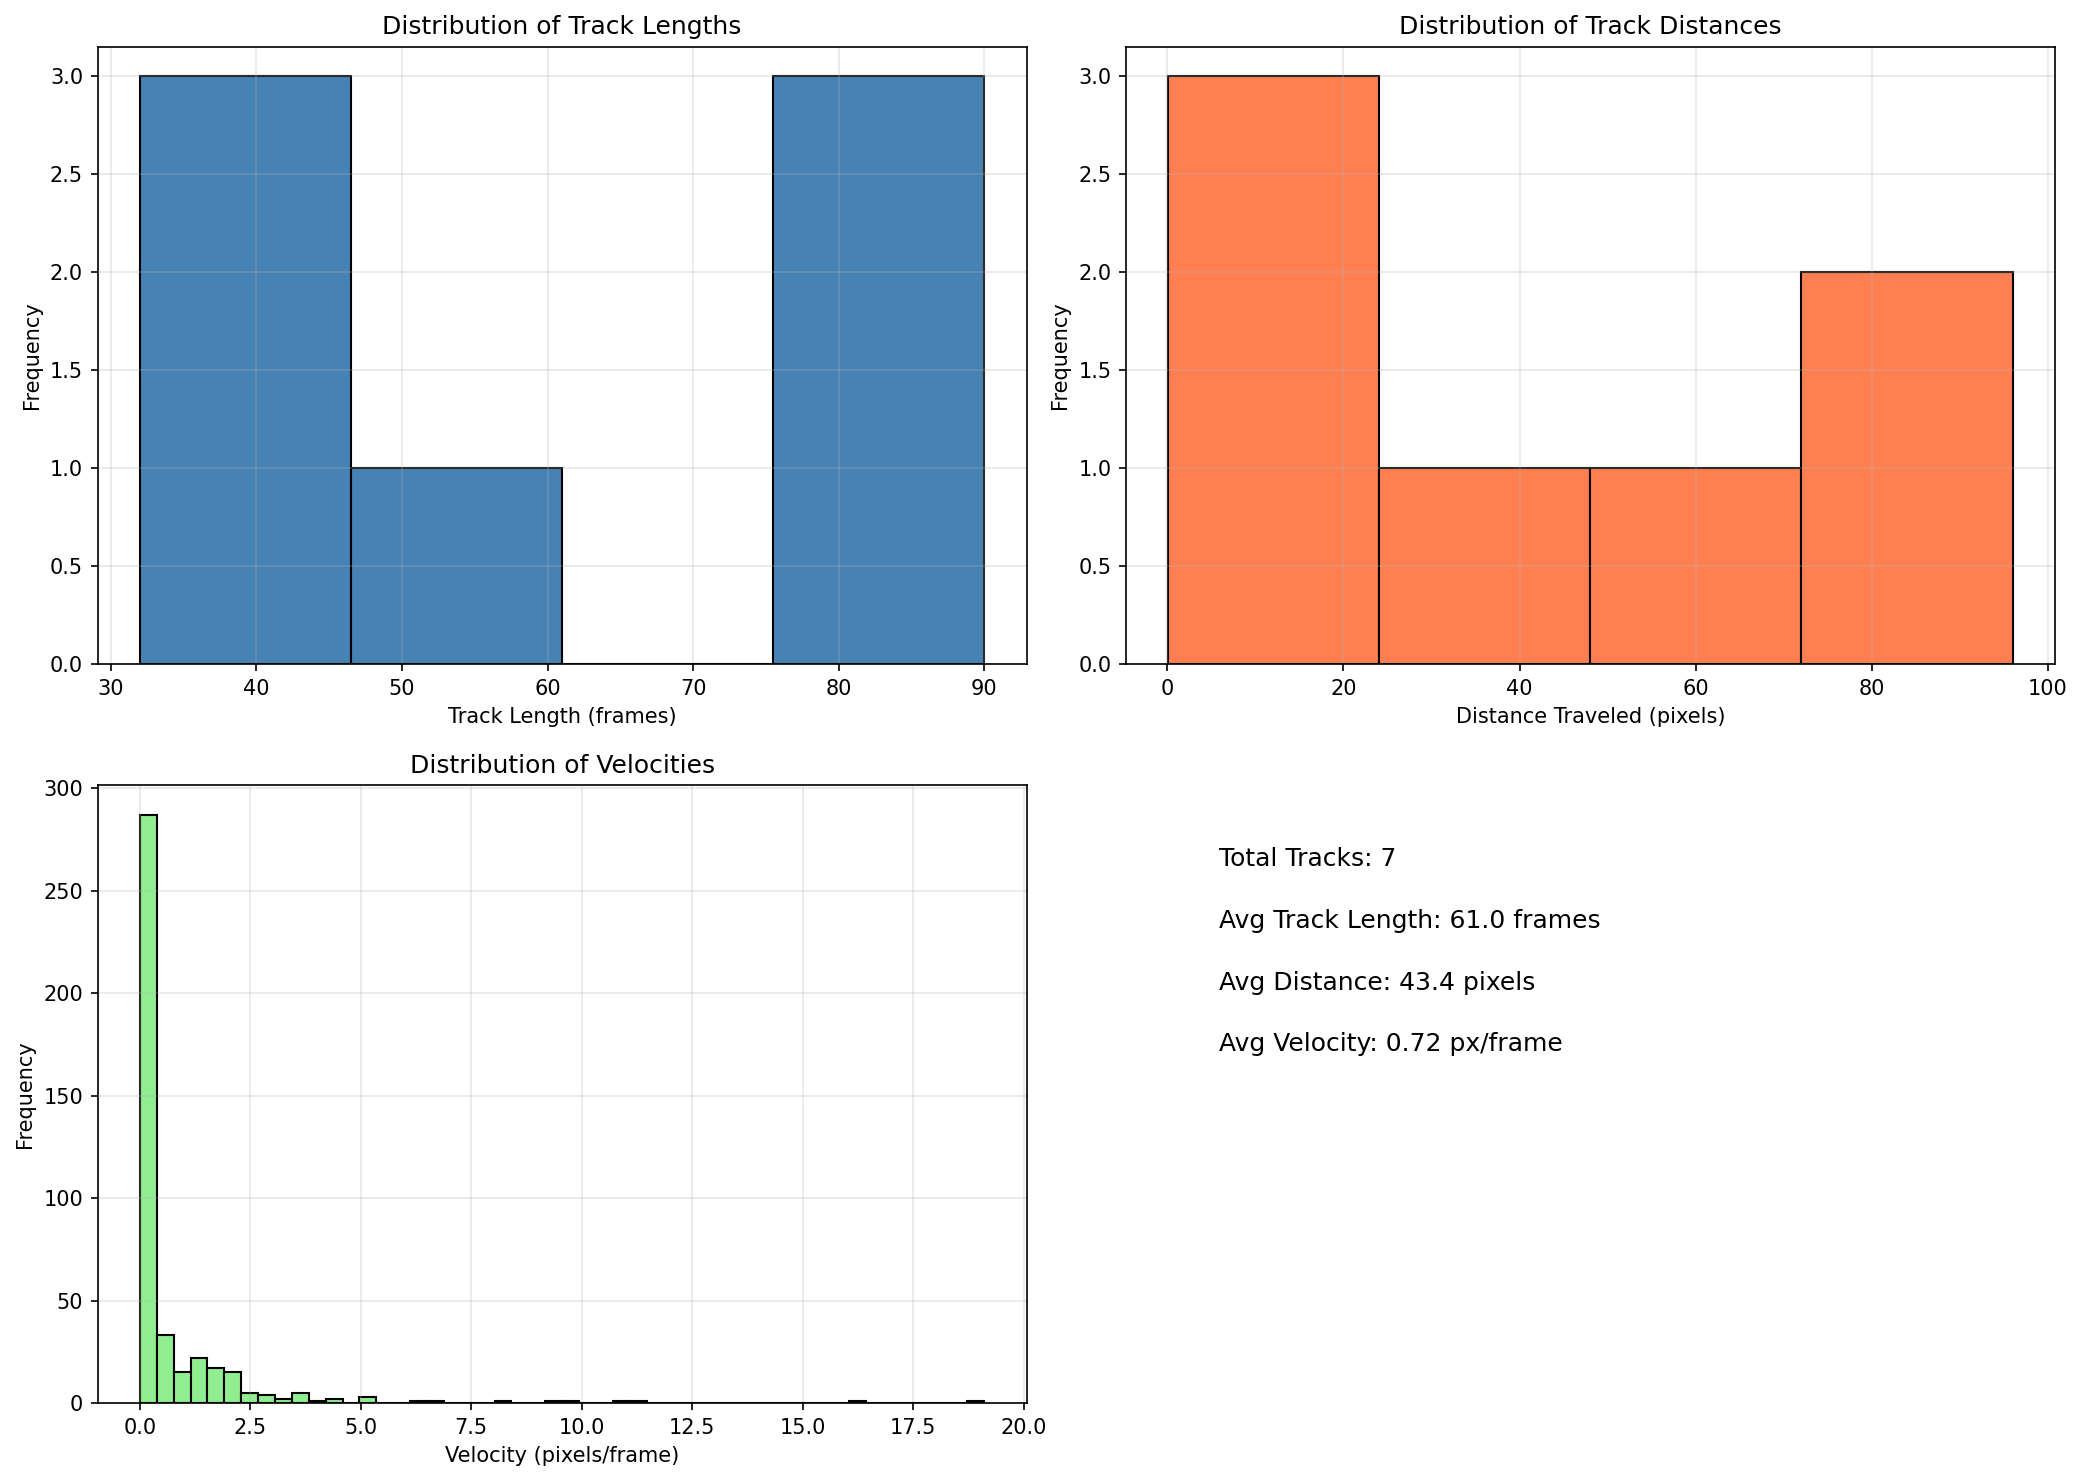


Trajectories Visualization:


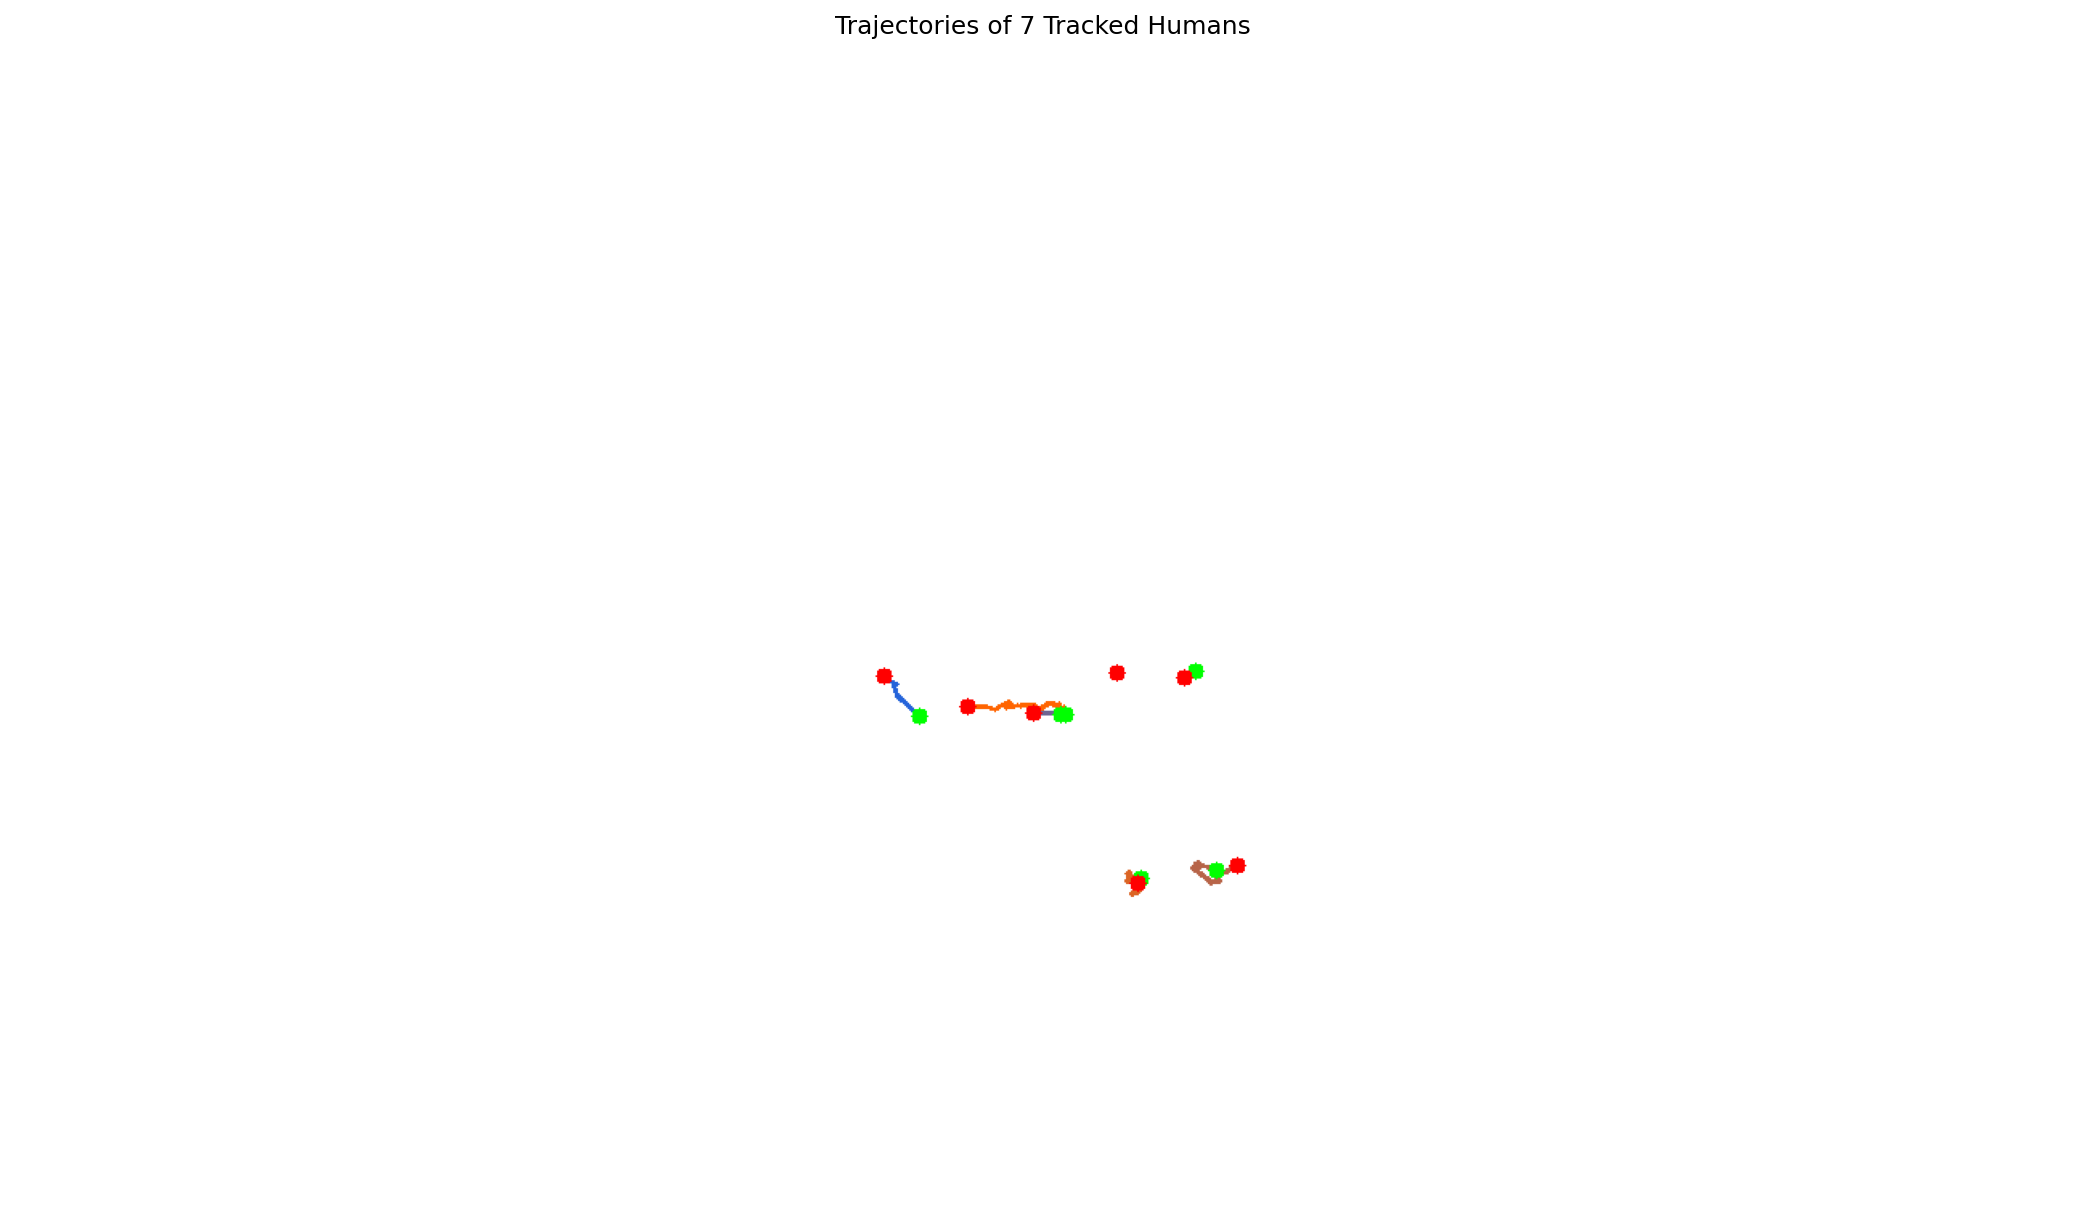

In [42]:
from IPython.display import Image, display

# Display statistics plot
stats_plot = OUTPUT_DIR / 'tracking_statistics.png'
if stats_plot.exists():
    print("Tracking Statistics Visualization:")
    display(Image(str(stats_plot)))

# Display trajectories plot
traj_plot = OUTPUT_DIR / 'trajectories_visualization.png'
if traj_plot.exists():
    print("\nTrajectories Visualization:")
    display(Image(str(traj_plot)))



## Cell 15: Create Detection Heatmap



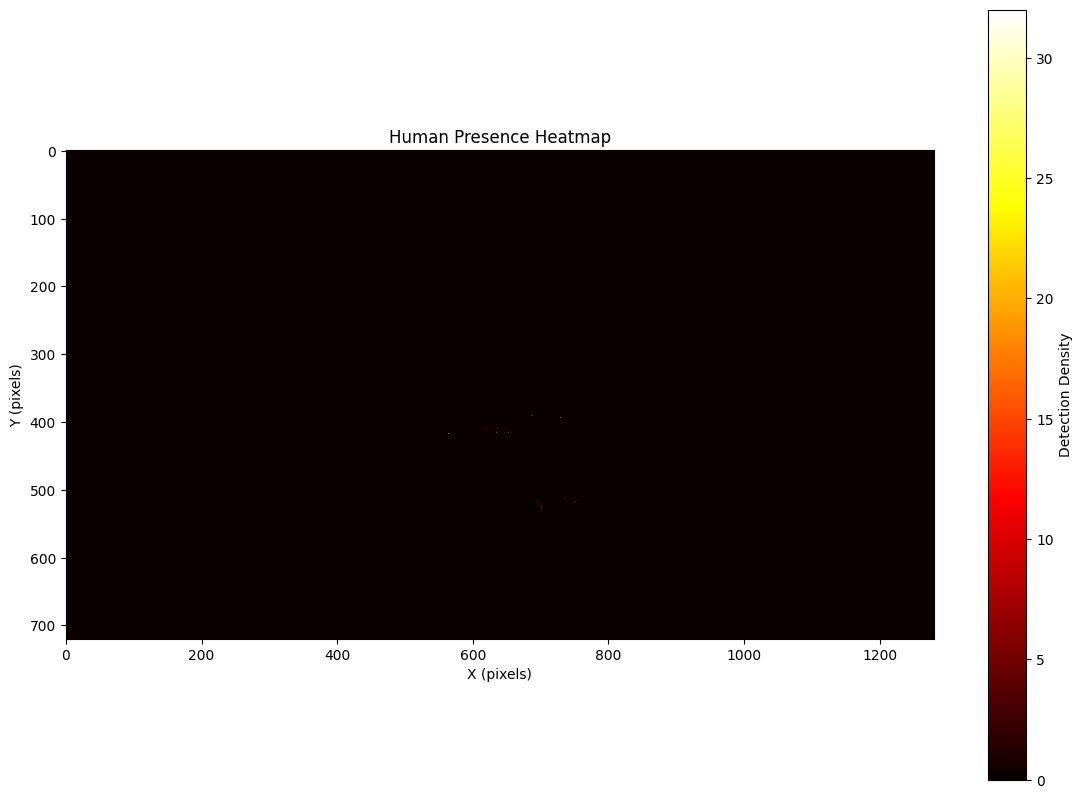

2026-03-31 16:43:06,848 - INFO - Heatmap saved to: /kaggle/working/tracking_results/detection_heatmap.png


In [43]:
if tracking_data and tracking_data['metadata']['width'] > 0:
    heatmap = np.zeros((tracking_data['metadata']['height'], tracking_data['metadata']['width']))
    
    for track_id, trajectory in tracking_data['tracks'].items():
        for entry in trajectory:
            cx, cy = int(entry['center'][0]), int(entry['center'][1])
            if 0 <= cy < heatmap.shape[0] and 0 <= cx < heatmap.shape[1]:
                heatmap[cy, cx] += 1
    
    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(heatmap, cmap='hot', origin='upper')
    ax.set_title('Human Presence Heatmap')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    plt.colorbar(im, ax=ax, label='Detection Density')
    
    heatmap_file = OUTPUT_DIR / 'detection_heatmap.png'
    plt.savefig(heatmap_file, dpi=150, bbox_inches='tight')
    plt.show()
    
    logger.info(f"Heatmap saved to: {heatmap_file}")



## Cell 16: Generate Statistics DataFrame



In [44]:
if tracking_data:
    tracks_data = []
    
    for track_id, trajectory in tracking_data['tracks'].items():
        positions = np.array([t['center'] for t in trajectory])
        distances = np.linalg.norm(np.diff(positions, axis=0), axis=1) if len(positions) > 1 else []
        
        track_info = {
            'Track ID': track_id,
            'Length (frames)': len(trajectory),
            'Duration (s)': (trajectory[-1]['frame_id'] - trajectory[0]['frame_id']) / tracking_data['metadata']['fps'],
            'Total Distance (px)': np.sum(distances),
            'Avg Velocity (px/f)': np.mean(distances) if len(distances) > 0 else 0,
            'Avg Confidence': np.mean([t['confidence'] for t in trajectory]),
            'Start Frame': trajectory[0]['frame_id'],
            'End Frame': trajectory[-1]['frame_id']
        }
        tracks_data.append(track_info)
    
    df_tracks = pd.DataFrame(tracks_data)
    
    print("\nTrack Statistics Summary:")
    print(df_tracks.to_string())
    
    # Save to CSV
    stats_csv = OUTPUT_DIR / 'track_details.csv'
    df_tracks.to_csv(stats_csv, index=False)
    print(f"\nDetailed statistics saved to: {stats_csv}")




Track Statistics Summary:
  Track ID  Length (frames)  Duration (s)  Total Distance (px)  Avg Velocity (px/f)  Avg Confidence  Start Frame  End Frame
0        0               90      2.966667            95.970202             1.078317        0.658089            0         89
1        1               90      2.966667            59.155088             0.664664        0.627206            0         89
2        2               87      2.866667            85.817122             0.997874        0.674138            3         89
3        3               37      1.200000             9.007957             0.250221        0.687707            3         39
4        4               55      1.800000            16.851917             0.312073        0.554917            9         63
5        5               32      1.033333             0.089639             0.002892        0.553748           30         61
6        6               36      1.166667            37.241927             1.064055        0.557251      

## Cell 17: Final Report



In [45]:
print("\n" + "=" * 70)
print("MULTI-HUMAN TRACKING PIPELINE - COMPLETE!")
print("=" * 70)
print(f"\nâœ“ All results saved to: {OUTPUT_DIR}")
print("\nGenerated Files:")
print("  - tracking_output.mp4 (annotated video)")
print("  - trajectories.json (detailed trajectories)")
print("  - trajectories.csv (trajectories in CSV format)")
print("  - tracking_statistics.png (statistical plots)")
print("  - trajectories_visualization.png (visual trajectories)")
print("  - detection_heatmap.png (detection density)")
print("  - tracking_summary.json (summary report)")
print("  - track_details.csv (detailed track info)")
print("\n" + "=" * 70)
print("SYSTEM READY FOR VIDEO ANALYSIS!")
print("=" * 70)



MULTI-HUMAN TRACKING PIPELINE - COMPLETE!

âœ“ All results saved to: /kaggle/working/tracking_results

Generated Files:
  - tracking_output.mp4 (annotated video)
  - trajectories.json (detailed trajectories)
  - trajectories.csv (trajectories in CSV format)
  - tracking_statistics.png (statistical plots)
  - trajectories_visualization.png (visual trajectories)
  - detection_heatmap.png (detection density)
  - tracking_summary.json (summary report)
  - track_details.csv (detailed track info)

SYSTEM READY FOR VIDEO ANALYSIS!
